L. Parker and S. M. Christensen, *MathTensor: A System for Doing Tensor Analysis by Computer* (Addison-Wesley, 1994)

In [1]:
<< mTensor`

# Chapter 6. Differential Form Applications

## 6.1 The Theorem of Stokes

In [2]:
Off[XDtoCDfrag]

2차원 시공간:

In [3]:
SetDimension[2]

In [4]:
Fdefine[w1, 1]

In [5]:
XD[w1]

XD[w1[]]

In [6]:
CoordRep[%, {x, y}]

(-BD[-2, w1[-1]] + BD[-1, w1[-2]]) XP[XD[x], XD[y]]

In [7]:
CoordRep[w1, {x, y}]

w1[-1] XD[x] + w1[-2] XD[y]

3차원 시공간:

In [8]:
SetDimension[3]

In [9]:
XD[w1]

XD[w1[]]

In [10]:
CoordRep[%, {x, y, z}]

(-BD[-2, w1[-1]] + BD[-1, w1[-2]]) XP[XD[x], XD[y]] + 
 
>   (-BD[-3, w1[-1]] + BD[-1, w1[-3]]) XP[XD[x], XD[z]] + 
 
>   (-BD[-3, w1[-2]] + BD[-2, w1[-3]]) XP[XD[y], XD[z]]

In [11]:
CoordRep[w1, {x, y, z}]

w1[-1] XD[x] + w1[-2] XD[y] + w1[-3] XD[z]

In [12]:
Fdefine[w2, 2]

In [13]:
XD[w2]

XD[w2[]]

In [14]:
CoordRep[%, {x, y, z}]

(BD[-3, w2[-1, -2]] - BD[-2, w2[-1, -3]] + BD[-1, w2[-2, -3]]) XP[XD[x], XD[y], XD[z]]

In [15]:
CoordRep[w2, {x, y, z}]

w2[-1, -2] XP[XD[x], XD[y]] + w2[-1, -3] XP[XD[x], XD[z]] + w2[-2, -3] XP[XD[y], XD[z]]

In [16]:
On[XDtoCDfrag]

## 6.2 Differential Forms and Maxwell's Equations

IndexedTensor를 이용한 막스웰 방정식1:

In [17]:
Tdefine[F, "2-"]; Tdefine[J, 1]

J[la]
CD[ub, F[la, lb]] - -----
                      2
                     c
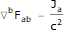

In [18]:
maxwellEq = CD[ub, F[la, lb]] - 1/c^2 J[la]

미분형식을 이용한 막스웰 방정식1:

In [19]:
Fdefine[f, 2]; Fdefine[j, 1]

In [20]:
CoXD[f]

CoXD[f]

In [21]:
ToTensor[%, {la}]

-CD[ub, f[lb, la]]

j
-(--) + CoXD[f]
   2
  c
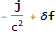

In [22]:
eqdiv = CoXD[f] - 1/c^2 j

j[la]
-CD[ub, f[lb, la]] - -----
                       2
                      c
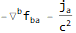

In [23]:
ToTensor[%, {la}]

IndexedTensor를 이용한 막스웰 방정식2 (비앙키 항등식):

CD[la, F[lb, lc]]   CD[la, F[lc, lb]]   CD[lb, F[la, lc]]   CD[lb, F[lc, la]]
----------------- - ----------------- - ----------------- + ----------------- + 
        2                   2                   2                   2
 
    CD[lc, F[la, lb]]   CD[lc, F[lb, la]]
>   ----------------- - -----------------
            2                   2
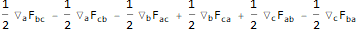

In [24]:
cycEq = 3*AntisymmetrizeIndices[{la, lb, lc}, CD[la, F[lb, lc]]]

In [25]:
% // TindexSort

CD[la, F[lb, lc]] - CD[lb, F[la, lc]] + CD[lc, F[la, lb]]

미분형식을 이용한 막스웰 방정식2 (비앙키 항등식):

In [26]:
XD[f]

XD[f[]]

In [27]:
ToTensor[%, {la, lb, lc}]

CD[la, f[lb, lc]] - CD[lb, f[la, lc]] + CD[lc, f[la, lb]]

벡터 포텐셜 1-form과 전자기장 2-form:

In [28]:
Fdefine[a, 1]

In [29]:
vecpotEq = f - XD[a]

f - XD[a[]]

In [30]:
ToTensor[%, {la, lb}]

-CD[la, a[lb]] + CD[lb, a[la]] + f[la, lb]

벡터 표텐셜 1-form을 이용한 막스웰 방정식2 (비앙키 항등식):

In [31]:
XD[vecpotEq]

XD[f[]]

벡터 표텐셜 1-form을 이용한 막스웰 방정식1:

j
-(--) + CoXD[XD[a[]]]
   2
  c
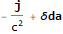

In [32]:
eqdiv2 = eqdiv /. f -> XD[a]

로렌츠 게이지 조건:

In [33]:
lorentz = CoXD[a]

CoXD[a]

In [34]:
ToTensor[lorentz, {}]

-CD[ua, a[la]]

로렌츠 게이지 조건을 부가하였을 때의 막스웰 방정식1:

j
-(--) + CoXD[XD[a[]]] + XD[CoXD[a]]
   2
  c
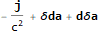

In [35]:
CoXD[XD[a]] + XD[CoXD[a]] - 1/c^2 j

j[la]
-CD[la, CD[lb, a[ub]]] + CD[ub, CD[la, a[lb]]] - CD[ub, CD[lb, a[la]]] - -----
                                                                           2
                                                                          c
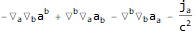

In [36]:
ToTensor[%, {la}]

j[la]
-CD[la, CD[lb, a[ub]]] + CD[ub, CD[la, a[lb]]] - CD[ub, CD[lb, a[la]]] - -----
                                                                           2
                                                                          c
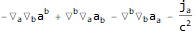

In [37]:
maxdivEq = %

In [38]:
maxdivEq[[1]] = CommuteCD[{la, lb}, maxdivEq[[1]]]

-CD[lb, CD[la, a[ub]]] + a[ub] RicciCD[la, lb]

따라서 로렌츠 게이지 조건을 부가하였을 때의

j[la]
-CD[lb, CD[ub, a[la]]] - ----- + a[lb] RicciCD[la, ub]
                           2
                          c
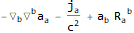

In [39]:
maxdivEq // Tsimplify

## 6.3 Tensor-valued Forms: Cartan Structure Equations

IndexedForm (basis 1-form, curvature 2-form, connection 1-form, torsion 2-form)을 정의한다:

In [40]:
Fdefine[e[ua], 1]; Fdefine[r[la, ub], 2];
Fdefine[w[la, ub], 1]; Fdefine[t[ua], 2]

In [42]:
XP[e[ua], e[ub]]

XP[e[ua], e[ub]]

In [43]:
ToTensor[%, {lm, ln}]

-(e[lm, ub] e[ln, ua]) + e[lm, ua] e[ln, ub]

In [44]:
r[la, ub]

r[la, ub]

In [45]:
ToTensor[%, {lm, ln}]

r[lm, ln, la, ub]

Cartan 방정식1:
$$
  t^a = de^a - e^p \wedge w_p^{\ \ a}
$$

In [47]:
cartan1 = XD[e[ua]] - XP[e[up], w[lp, ua]] - t[ua]

-t[ua] + XD[e[ua]] - XP[e[up], w[lp, ua]]

In [48]:
cartan1Rule = RuleUnique[XD[e[ua_]], t[ua] + XP[e[up], w[lp, ua]]]

XD[e[ua_]] :> DumFresh[t[ua] + XP[e[u$22], w[l$22, ua]]]

Cartan 방정식2:
$$
  r_a^{\ \ b} = dw_a^{\ \ b} - w_a^{\ \ p} \wedge w_p^{\ \ b}
$$

In [49]:
cartan2 = XD[w[la, ub]] - XP[w[la, up], w[lp, ub]] - r[la, ub]

-r[la, ub] + XD[w[la, ub]] - XP[w[la, up], w[lp, ub]]

In [50]:
cartan2Rule = 
 RuleUnique[XD[w[la_, ub_]], r[la, ub] + XP[w[la, up], w[lp, ub]]]

XD[w[la_, ub_]] :> DumFresh[r[la, ub] + XP[w[la, u$23], w[l$23, ub]]]

In [51]:
cartanRule = {cartan1Rule, cartan2Rule}

{XD[e[ua_]] :> DumFresh[t[ua] + XP[e[u$22], w[l$22, ua]]], 
 
>   XD[w[la_, ub_]] :> DumFresh[r[la, ub] + XP[w[la, u$23], w[l$23, ub]]]}

미분형식으로 표현된 비앙키 항등식 1:
$$
  dt^a = e^p \wedge r_p^{\ \ a} - w_p^{\ \ a} \wedge t^p
$$

In [52]:
XD[cartan1]

-XD[t[ua]] + XP[e[up], XD[w[lp, ua]]] - XP[w[lp, ua], XD[e[up]]]

In [53]:
% /. cartanRule

-XD[t[ua]] + XP[e[up], r[lp, ua]] - XP[w[lp, ua], t[up]] - 
 
>   XP[e[ub], w[lb, up], w[lp, ua]] - XP[e[up], w[lb, ua], w[lp, ub]]

In [54]:
% // Dum

-XD[t[ua]] + XP[e[ub], r[lb, ua]] - XP[w[lb, ua], t[ub]]

In [55]:
ToTensor[%, {lp, lq, lr}]

-CD[lp, t[lq, lr, ua]] + CD[lq, t[lp, lr, ua]] - CD[lr, t[lp, lq, ua]] + 
 
>   e[lr, ub] r[lp, lq, lb, ua] - e[lq, ub] r[lp, lr, lb, ua] + 
 
>   e[lp, ub] r[lq, lr, lb, ua] - t[lq, lr, ub] w[lp, lb, ua] + 
 
>   t[lp, lr, ub] w[lq, lb, ua] - t[lp, lq, ub] w[lr, lb, ua]

미분형식으로 표현된 비앙키 항등식 2:
$$
  dr_a^{\ \ b} = w_a^{\ \ p} \wedge r_p^{\ \ b}
  - w_p^{\ \ b} \wedge r_a^{\ \ p}
$$

In [56]:
XD[cartan2]

-XD[r[la, ub]] + XP[w[la, up], XD[w[lp, ub]]] - XP[w[lp, ub], XD[w[la, up]]]

In [57]:
% /. cartanRule

-XD[r[la, ub]] + XP[w[la, up], r[lp, ub]] - XP[w[lp, ub], r[la, up]] - 
 
>   XP[w[la, uc], w[lc, up], w[lp, ub]] - XP[w[la, up], w[lc, ub], w[lp, uc]]

In [58]:
% // Dum

-XD[r[la, ub]] + XP[w[la, uc], r[lc, ub]] - XP[w[lc, ub], r[la, uc]]

In [59]:
bianchi = %;

IndexedForm 표현과 IndexedTensor 표현의 비교:

In [60]:
cartan2

-r[la, ub] + XD[w[la, ub]] - XP[w[la, up], w[lp, ub]]

In [61]:
Off[XDtoCDfrag]

In [62]:
ToTensor[%%, {ld, le}]

BD[ld, w[le, la, ub]] - BD[le, w[ld, la, ub]] - r[ld, le, la, ub] + 
 
>   w[ld, lc, ub] w[le, la, uc] - w[ld, la, uc] w[le, lc, ub]

In [63]:
Off[XDtoCDfrag]  (* default *)

In [64]:
RiemannToGamma[RiemannCD[ld, le, la, ub]]

-BD[ld, GammaCD[le, la, ub]] + BD[le, GammaCD[ld, la, ub]] - 
 
>   GammaCD[ld, lc, ub] GammaCD[le, la, uc] + GammaCD[ld, la, uc] GammaCD[le, lc, ub]

따라서 $\Gamma_{ab}^{\ \ \ \ c} = w_{ab}^{\ \ \ \ c}$. Torsion-free인 경우 $w_{ab}^{\ \ \ \ c} = w_{(ab)}^{\ \ \ \ \ \ c}$.

In [85]:
bianchi

-XD[r[la, ub]] + XP[w[la, uc], r[lc, ub]] - XP[w[lc, ub], r[la, uc]]

In [86]:
ToTensor[%, {lc, ld, le}]

-BD[lc, r[ld, le, la, ub]] + BD[ld, r[lc, le, la, ub]] - BD[le, r[lc, ld, la, ub]] + 
 
>   r[ld, le, lf, ub] w[lc, la, uf] - r[ld, le, la, uf] w[lc, lf, ub] - 
 
>   r[lc, le, lf, ub] w[ld, la, uf] + r[lc, le, la, uf] w[ld, lf, ub] + 
 
>   r[lc, ld, lf, ub] w[le, la, uf] - r[lc, ld, la, uf] w[le, lf, ub]

이것은 torsion-free일 때의 비앙키 항등식 $\nabla_{[c} r_{de]a}^{\ \ \ \ \ \ \ b} = 0$이 된다.

## 6.4 Structure Equations in Euclidean Space